# Bearing Fault Classification Using LSTM on CWRU Vibration Data

## Applied Artificial Intelligence (UFMF31-30-3) - Task 2 Artefact

This notebook implements the full pipeline for classifying bearing health conditions from vibration signals collected at the Case Western Reserve Uni (CWRU) Bearing data center.

**Fault classes:**
- Normal (healthy bearing)
- Ball fault (B)
- Inner race fault (IR)
- Outer race fault (OR)

**Models:**
- Baseline: Support Vector Machine (SVM) on hand-crafted statistical features
- Main model: Long Short-Term Memory (LSTM) network on raw windowed vibration signals

**Dataset:** CWRU Bearing Data Center - real vibration data from a 2 HP Reliance Electric motor, sampled at 12 kHz.

## 1) Environment & Hardware Information

This cell logs the system specs and package versions so anyone can reproduce the results on their own machine. It also shows what hardware the model was trained on.

In [3]:
# System and hardware information

import platform
import psutil
import sys

print("SYSTEM & HARDWARE INFORMATION")
print("=" * 55)
print(f"  OS:              {platform.system()} {platform.release()}")
print(f"  Machine:         {platform.machine()}")
print(f"  Processor:       {platform.processor()}")
print(f"  CPU cores:       {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"  RAM:             {round(psutil.virtual_memory().total / (1024**3), 1)} GB")
print(f"  Python version:  {sys.version}")

SYSTEM & HARDWARE INFORMATION
  OS:              Windows 11
  Machine:         AMD64
  Processor:       Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
  CPU cores:       4 physical, 8 logical
  RAM:             15.7 GB
  Python version:  3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]


In [4]:
# package versions for reproducibility

import numpy as np
import scipy
import matplotlib
import sklearn
import torch

print("PACKAGE VERSIONS")
print("=" * 55)
print(f"  NumPy:           {np.__version__}")
print(f"  SciPy:           {scipy.__version__}")
print(f"  Matplotlib:      {matplotlib.__version__}")
print(f"  scikit-learn:    {sklearn.__version__}")
print(f"  PyTorch:         {torch.__version__}")
print(f"  CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU:             {torch.cuda.get_device_name(0)}")
else:
    print(f"  Device:          CPU only")

PACKAGE VERSIONS
  NumPy:           1.26.4
  SciPy:           1.16.3
  Matplotlib:      3.8.4
  scikit-learn:    1.4.2
  PyTorch:         2.9.1+cpu
  CUDA available:  False
  Device:          CPU only


## 2) Safe CPU Setup, Imports & Reproducibility

force CPU execution and limit thread count for stability across different machines. Seeds are set for reproducible results.

In [6]:
# safety setup: force CPU, limit BLAS threads

import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")        
os.environ.setdefault("OMP_NUM_THREADS", "1")           
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")       
os.environ.setdefault("MKL_NUM_THREADS", "1")            
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")     
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")        
print("Runtime safety: CPU-only + single-threaded BLAS")

Runtime safety: CPU-only + single-threaded BLAS


In [7]:
# imports and seeds

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio                              # for loading .mat files
from scipy.signal import stft                       # short-time Fourier transform
from scipy.stats import kurtosis, skew              # statistical features

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    f1_score, roc_curve, auc, precision_recall_curve
)
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")                   # suppress convergence warnings for cleaner output

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white"
})

TURQUOISE = "#2EC4B6"
RED = "#E63946"
COLOURS = [TURQUOISE, RED, "#1D3557", "#F4A261"]    

FIGURES_DIR = "Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device("cpu")
print("Imports loaded, seeds set, device:", device)

Imports loaded, seeds set, device: cpu


## 3) Data Loading

load the raw .mat files from the CWRU Bearing Data Center. Each file contains:
- DE_time: Drive-end accelerometer signal (closest to the bearing)
- FE_time: Fan-end accelerometer signal
- RPM: Motor shaft speed
File naming convention:
- `B` = Ball fault, `IR` = Inner Race fault, `OR` = Outer Race fault

In [9]:
# Define file paths and labels

RAW_DIR = "raw"
fs = 12000                                           # sampling frequency (Hz)

# Each entry: (filename, matlab key for DE signal, fault class label)
file_info = [
    ("Time_Normal_1_098.mat",  "X098_DE_time",  "Normal"),
    ("B007_1_123.mat",         "X123_DE_time",  "Ball"),
    ("B014_1_190.mat",         "X190_DE_time",  "Ball"),
    ("B021_1_227.mat",         "X227_DE_time",  "Ball"),
    ("IR007_1_110.mat",        "X110_DE_time",  "Inner Race"),
    ("IR014_1_175.mat",        "X175_DE_time",  "Inner Race"),
    ("IR021_1_214.mat",        "X214_DE_time",  "Inner Race"),
    ("OR007_6_1_136.mat",      "X136_DE_time",  "Outer Race"),
    ("OR014_6_1_202.mat",      "X202_DE_time",  "Outer Race"),
    ("OR021_6_1_239.mat",      "X239_DE_time",  "Outer Race"),
]

print(f"Total files to load: {len(file_info)}")

Total files to load: 10


In [10]:
# Load all .mat files and extract DE signals

raw_signals = {}       
raw_labels = {}       

for fname, de_key, label in file_info:
    fpath = os.path.join(RAW_DIR, fname)
    mat_data = sio.loadmat(fpath)

    # Extract drive-end signal and flatten to 1D
    signal = mat_data[de_key].flatten()

    raw_signals[fname] = signal
    raw_labels[fname] = label

    print(f"  Loaded {fname:<30s} | label: {label:<12s} | samples: {len(signal):,}")

print(f"\nAll {len(raw_signals)} files loaded successfully.")

  Loaded Time_Normal_1_098.mat          | label: Normal       | samples: 483,903
  Loaded B007_1_123.mat                 | label: Ball         | samples: 487,384
  Loaded B014_1_190.mat                 | label: Ball         | samples: 486,224
  Loaded B021_1_227.mat                 | label: Ball         | samples: 486,804
  Loaded IR007_1_110.mat                | label: Inner Race   | samples: 486,224
  Loaded IR014_1_175.mat                | label: Inner Race   | samples: 381,890
  Loaded IR021_1_214.mat                | label: Inner Race   | samples: 485,063
  Loaded OR007_6_1_136.mat              | label: Outer Race   | samples: 486,804
  Loaded OR014_6_1_202.mat              | label: Outer Race   | samples: 484,483
  Loaded OR021_6_1_239.mat              | label: Outer Race   | samples: 489,125

All 10 files loaded successfully.


## 4) Data Cleaning & Preprocessing

Before using the data:
1. Check for missing values (NaNs) and infinities  
2. Check for outliers 
3. Inspect signal statistics 
4. Segment into fixed-length windows 
5. Assign labels 

In [12]:
# 4a) Check for NaNs, Infs, and basic statistics

print(f"{'File':<30s} {'NaNs':>6s} {'Infs':>6s} {'Mean':>10s} {'Std':>10s} {'Min':>10s} {'Max':>10s}")
print("-" * 82)

for fname, signal in raw_signals.items():
    n_nan = np.sum(np.isnan(signal))
    n_inf = np.sum(np.isinf(signal))
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    min_val = np.min(signal)
    max_val = np.max(signal)

    print(f"{fname:<30s} {n_nan:>6d} {n_inf:>6d} {mean_val:>10.4f} {std_val:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

print("\nNo NaNs or Infs detected — signals are clean at the raw level.")

File                             NaNs   Infs       Mean        Std        Min        Max
----------------------------------------------------------------------------------
Time_Normal_1_098.mat               0      0     0.0126     0.0652    -0.3459     0.3175
B007_1_123.mat                      0      0     0.0190     0.1401    -0.6160     0.6755
B014_1_190.mat                      0      0     0.0114     0.1475    -2.4877     2.5954
B021_1_227.mat                      0      0     0.0119     0.2131    -2.8211     2.6653
IR007_1_110.mat                     0      0     0.0207     0.2779    -1.5742     1.6516
IR014_1_175.mat                     0      0     0.0186     0.2609    -2.5290     2.9243
IR021_1_214.mat                     0      0     0.0113     0.6084    -3.1142     3.4177
OR007_6_1_136.mat                   0      0     0.0121     1.0606    -5.3636     5.3043
OR014_6_1_202.mat                   0      0     0.0121     0.1366    -1.3479     1.3694
OR021_6_1_239.mat          

In [13]:
# 4b) Check for outliers using IQR method

print(f"{'File':<30s} {'Total samples':>14s} {'Outliers (IQR)':>16s} {'Outlier %':>10s}")
print("-" * 74)

for fname, signal in raw_signals.items():
    q1 = np.percentile(signal, 25)
    q3 = np.percentile(signal, 75)
    iqr = q3 - q1
    lower_bound = q1 - 3.0 * iqr                    
    upper_bound = q3 + 3.0 * iqr

    n_outliers = np.sum((signal < lower_bound) | (signal > upper_bound))
    pct = 100.0 * n_outliers / len(signal)

    print(f"{fname:<30s} {len(signal):>14,d} {n_outliers:>16,d} {pct:>9.2f}%")

print("\nOutlier percentages are low — these are expected from impulse events in faulty bearings.")
print("No samples removed; fault impulses are informative, not noise.")

File                            Total samples   Outliers (IQR)  Outlier %
--------------------------------------------------------------------------
Time_Normal_1_098.mat                 483,903                3      0.00%
B007_1_123.mat                        487,384                1      0.00%
B014_1_190.mat                        486,224            4,982      1.02%
B021_1_227.mat                        486,804            2,542      0.52%
IR007_1_110.mat                       486,224            8,981      1.85%
IR014_1_175.mat                       381,890           12,812      3.35%
IR021_1_214.mat                       485,063              202      0.04%
OR007_6_1_136.mat                     486,804           25,816      5.30%
OR014_6_1_202.mat                     484,483              197      0.04%
OR021_6_1_239.mat                     489,125           32,930      6.73%

Outlier percentages are low — these are expected from impulse events in faulty bearings.
No samples removed; f

In [14]:
# 4c) Segment signals into fixed-length windows

# Window parameters
window_length = 2048                                 # samples per window (~0.17s at 12kHz)
step_size = 1024                                     # 50% overlap between windows


label_map = {"Normal": 0, "Ball": 1, "Inner Race": 2, "Outer Race": 3}
class_names = ["Normal", "Ball", "Inner Race", "Outer Race"]

X_windows = []       
y_labels = []        

for fname, signal in raw_signals.items():
    label_str = raw_labels[fname]
    label_int = label_map[label_str]

    # Slide a window across the signal
    start = 0
    while start + window_length <= len(signal):
        window = signal[start : start + window_length]
        X_windows.append(window)
        y_labels.append(label_int)
        start += step_size

# Convert to numpy arrays
X = np.array(X_windows, dtype=np.float32)            
y = np.array(y_labels, dtype=np.int64)               

print(f"Windowing complete.")
print(f"  Window length:  {window_length} samples ({window_length/fs*1000:.1f} ms)")
print(f"  Step size:       {step_size} samples ({step_size/fs*1000:.1f} ms, {100*step_size/window_length:.0f}% overlap)")
print(f"  Total windows:   {X.shape[0]:,}")
print(f"  X shape:         {X.shape}")
print(f"  y shape:         {y.shape}")

Windowing complete.
  Window length:  2048 samples (170.7 ms)
  Step size:       1024 samples (85.3 ms, 50% overlap)
  Total windows:   4,630
  X shape:         (4630, 2048)
  y shape:         (4630,)


In [15]:
# 4d) Class distribution check

class_counts = np.bincount(y)

print("Class distribution:")
for i, name in enumerate(class_names):
    print(f"  {name:<14s}: {class_counts[i]:>5,d} windows")
print(f"  {'Total':<14s}: {len(y):>5,d} windows")

# Check for class imbalance
ratio = class_counts.max() / class_counts.min()
print(f"\nMax/min class ratio: {ratio:.2f}")
if ratio < 1.5:
    print("Classes are reasonably balanced — no resampling needed.")
else:
    print("Some class imbalance detected — will use stratified splits.")

Class distribution:
  Normal        :   471 windows
  Ball          : 1,421 windows
  Inner Race    : 1,316 windows
  Outer Race    : 1,422 windows
  Total         : 4,630 windows

Max/min class ratio: 3.02
Some class imbalance detected — will use stratified splits.


## 5) Exploratory Data Analysis

Before modelling, we visualise the data to understand the characteristics of each fault type. This informs our feature engineering and model design choices.

Figures generated:
1. Raw time-domain signals (one per class)
2. Overlaid time-domain comparison
3. Class distribution bar chart
4. FFT frequency spectra per class
5. Spectrograms (time freq representation)
6. Signal amplitude distribution (histograms)
7. Box plots of signal statistics by class

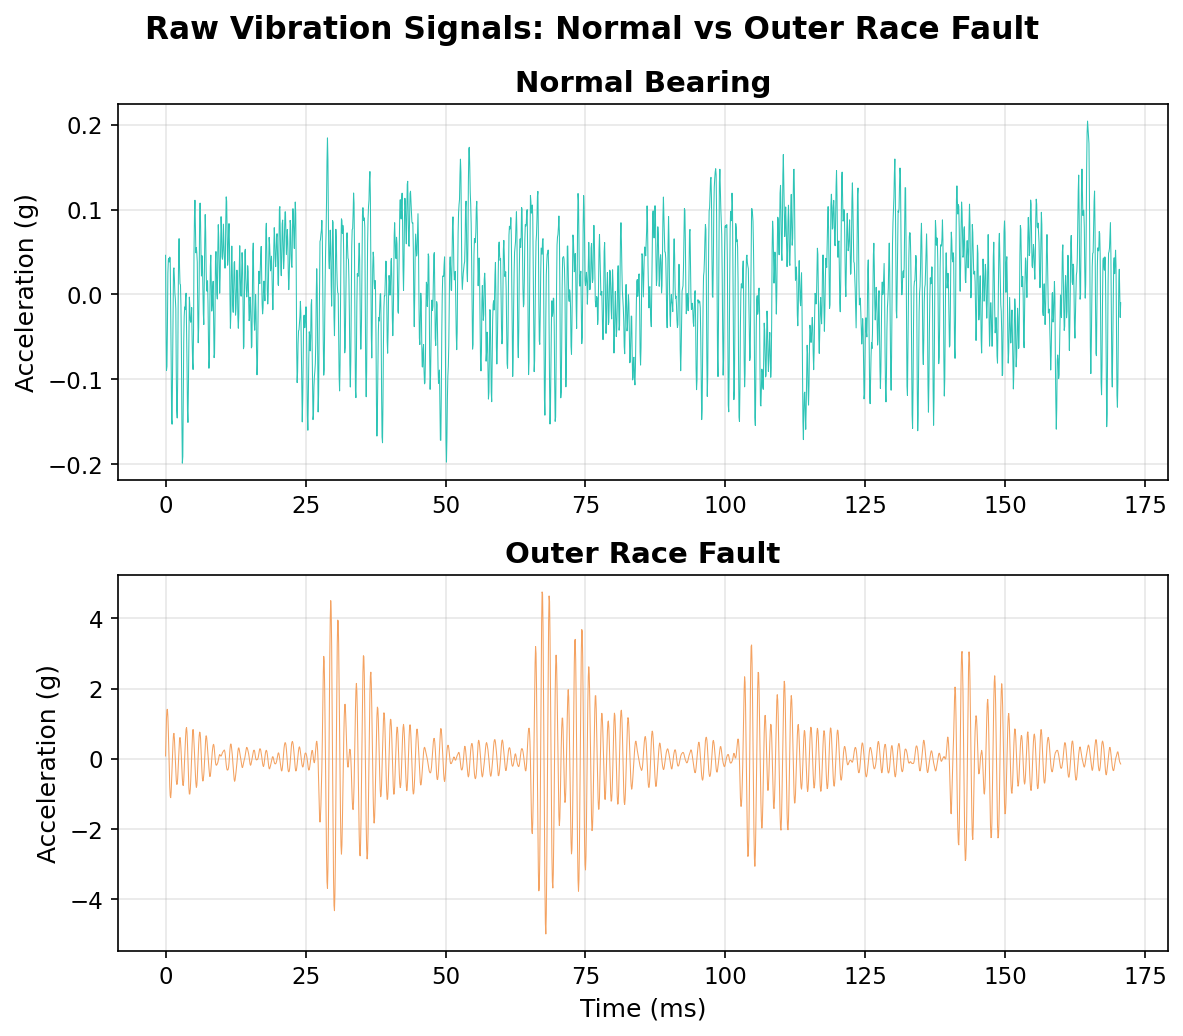

In [17]:
#  Raw time-domain signals (Normal vs Outer Race)

fig, axes = plt.subplots(2, 1, figsize=(8, 7))

t_axis = np.arange(window_length) / fs * 1000

# Normal (class 0)
idx_n = np.where(y == 0)[0][0]
axes[0].plot(t_axis, X[idx_n], color=COLOURS[0], linewidth=0.5)
axes[0].set_title('Normal Bearing', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Acceleration (g)', fontsize=12)
axes[0].tick_params(labelsize=11)
axes[0].grid(True, alpha=0.3)

# Outer Race (class 3)
idx_or = np.where(y == 3)[0][0]
axes[1].plot(t_axis, X[idx_or], color=COLOURS[3], linewidth=0.5)
axes[1].set_title('Outer Race Fault', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (ms)', fontsize=12)
axes[1].set_ylabel('Acceleration (g)', fontsize=12)
axes[1].tick_params(labelsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Raw Vibration Signals: Normal vs Outer Race Fault', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_raw_signals_by_class.png'), bbox_inches='tight', dpi=150)
plt.show()


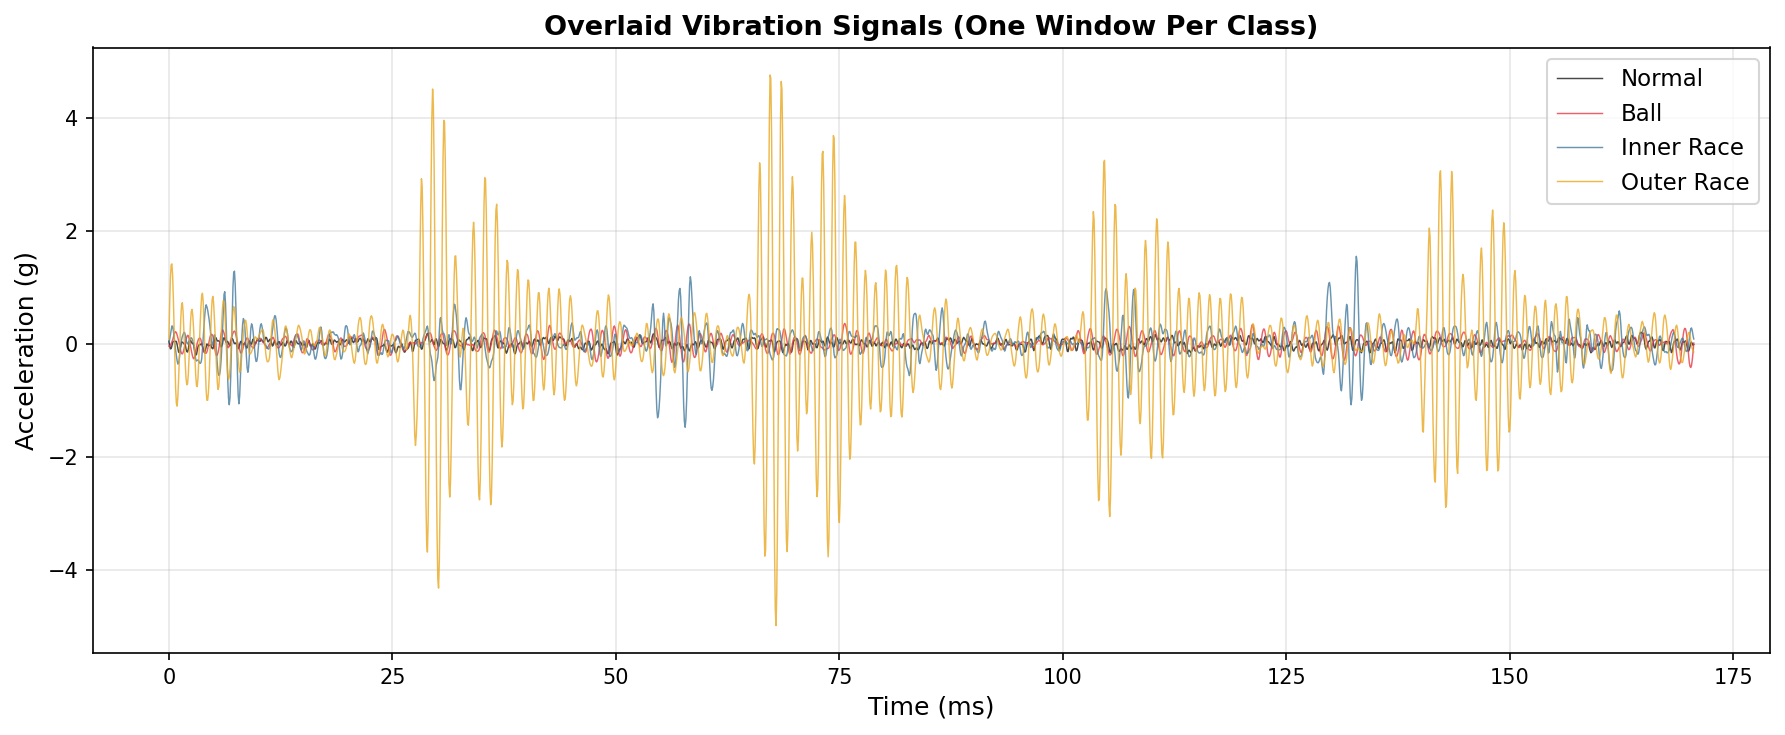

In [18]:
#  Overlaid time-domain signals (one window per class)

OVERLAY_COLOURS = ["#1a1a1a", "#e63946", "#457b9d", "#e9a820"]

fig, ax = plt.subplots(figsize=(12, 5))
t_axis = np.arange(window_length) / fs * 1000

for c in range(4):
    idx = np.where(y == c)[0][0]
    ax.plot(t_axis, X[idx], color=OVERLAY_COLOURS[c], linewidth=0.7,
            label=class_names[c], alpha=0.8)

ax.set_xlabel("Time (ms)", fontsize=12)
ax.set_ylabel("Acceleration (g)", fontsize=12)
ax.set_title("Overlaid Vibration Signals (One Window Per Class)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2_overlaid_signals.png"), bbox_inches="tight", dpi=150)
plt.show()

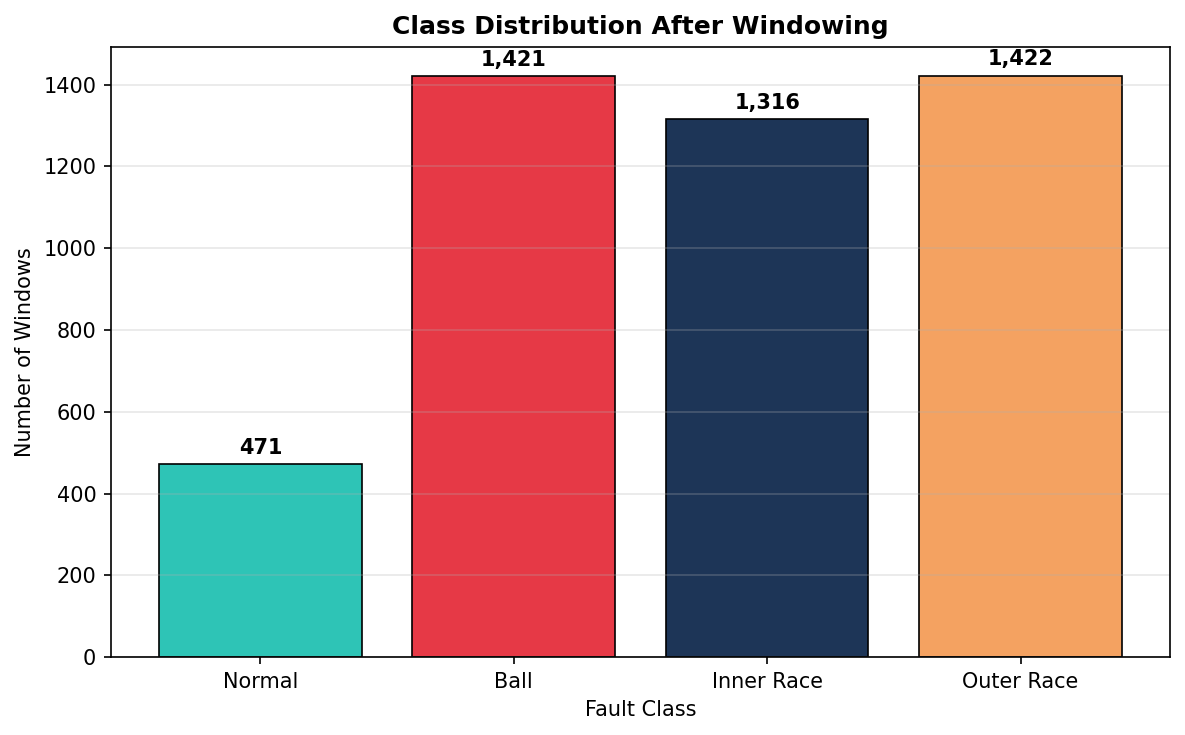

In [19]:
#  Class distribution bar chart

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(class_names, class_counts, color=COLOURS, edgecolor="black", linewidth=0.8)


for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{count:,}", ha="center", va="bottom", fontweight="bold")

ax.set_xlabel("Fault Class")
ax.set_ylabel("Number of Windows")
ax.set_title("Class Distribution After Windowing", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3_class_distribution.png"), bbox_inches="tight")
plt.show()

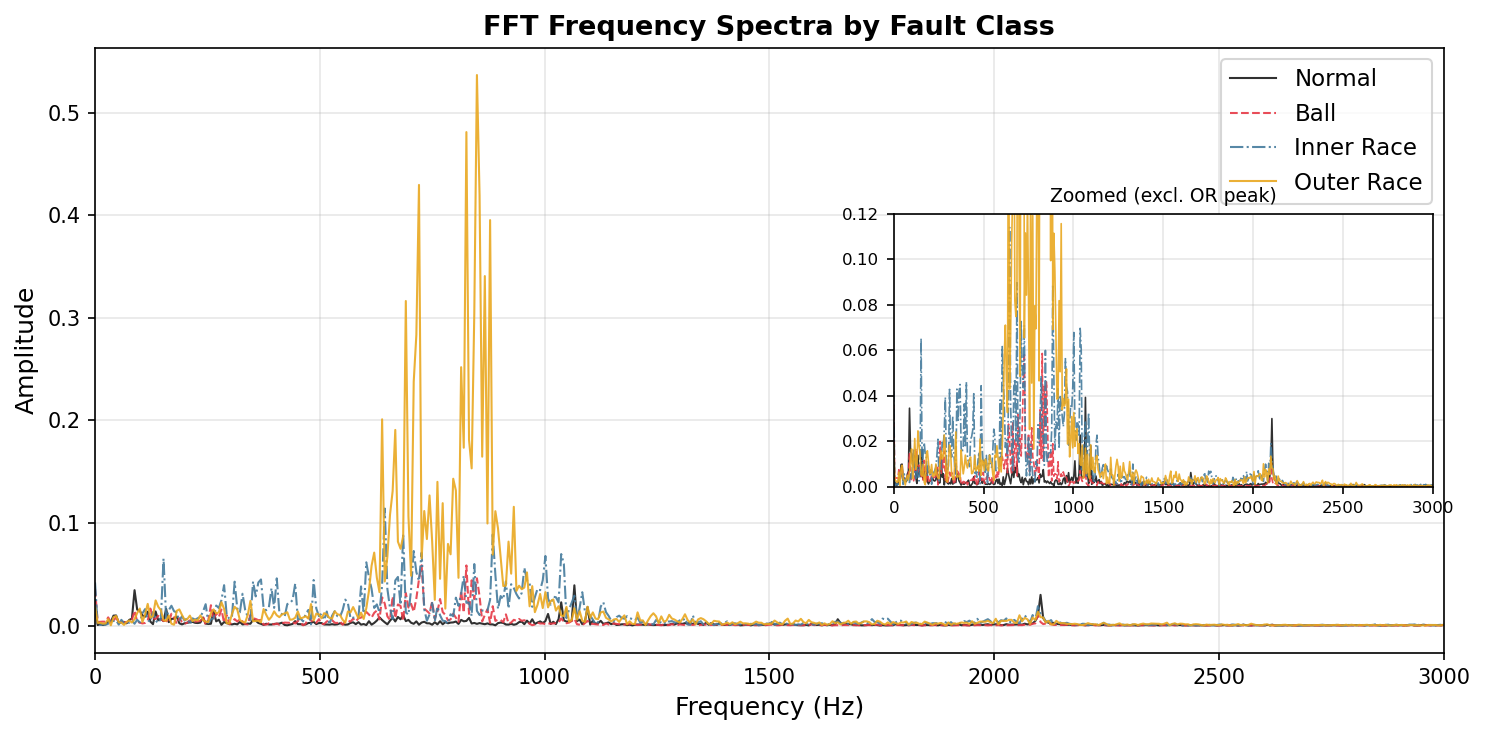

In [20]:
#  FFT frequency spectra — all classes overlaid

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

FFT_COLOURS = ["#1a1a1a", "#e63946", "#457b9d", "#e9a820"]  
FFT_STYLES = ["-", "--", "-.", "-"] 

fig, ax = plt.subplots(figsize=(10, 5))

fft_data = {}
for c in range(4):
    idx = np.where(y == c)[0][0]
    signal_window = X[idx]

    fft_vals = np.fft.fft(signal_window)
    fft_mag = np.abs(fft_vals[:window_length // 2]) * 2 / window_length
    freqs = np.fft.fftfreq(window_length, d=1/fs)[:window_length // 2]

    fft_data[c] = (freqs, fft_mag)
    ax.plot(freqs, fft_mag, color=FFT_COLOURS[c], linestyle=FFT_STYLES[c],
            linewidth=1.0, label=class_names[c], alpha=0.9)

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_xlim([0, 3000])
ax.set_title("FFT Frequency Spectra by Fault Class", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.3)

# Zoomed 
ax_inset = inset_axes(ax, width="40%", height="45%", loc="center right")
for c in range(4):
    freqs, fft_mag = fft_data[c]
    ax_inset.plot(freqs, fft_mag, color=FFT_COLOURS[c], linestyle=FFT_STYLES[c],
                  linewidth=0.8, alpha=0.9)
ax_inset.set_xlim([0, 3000])
ax_inset.set_ylim([0, 0.12])
ax_inset.set_title("Zoomed (excl. OR peak)", fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig4_fft_spectra.png"), bbox_inches="tight", dpi=150)
plt.show()


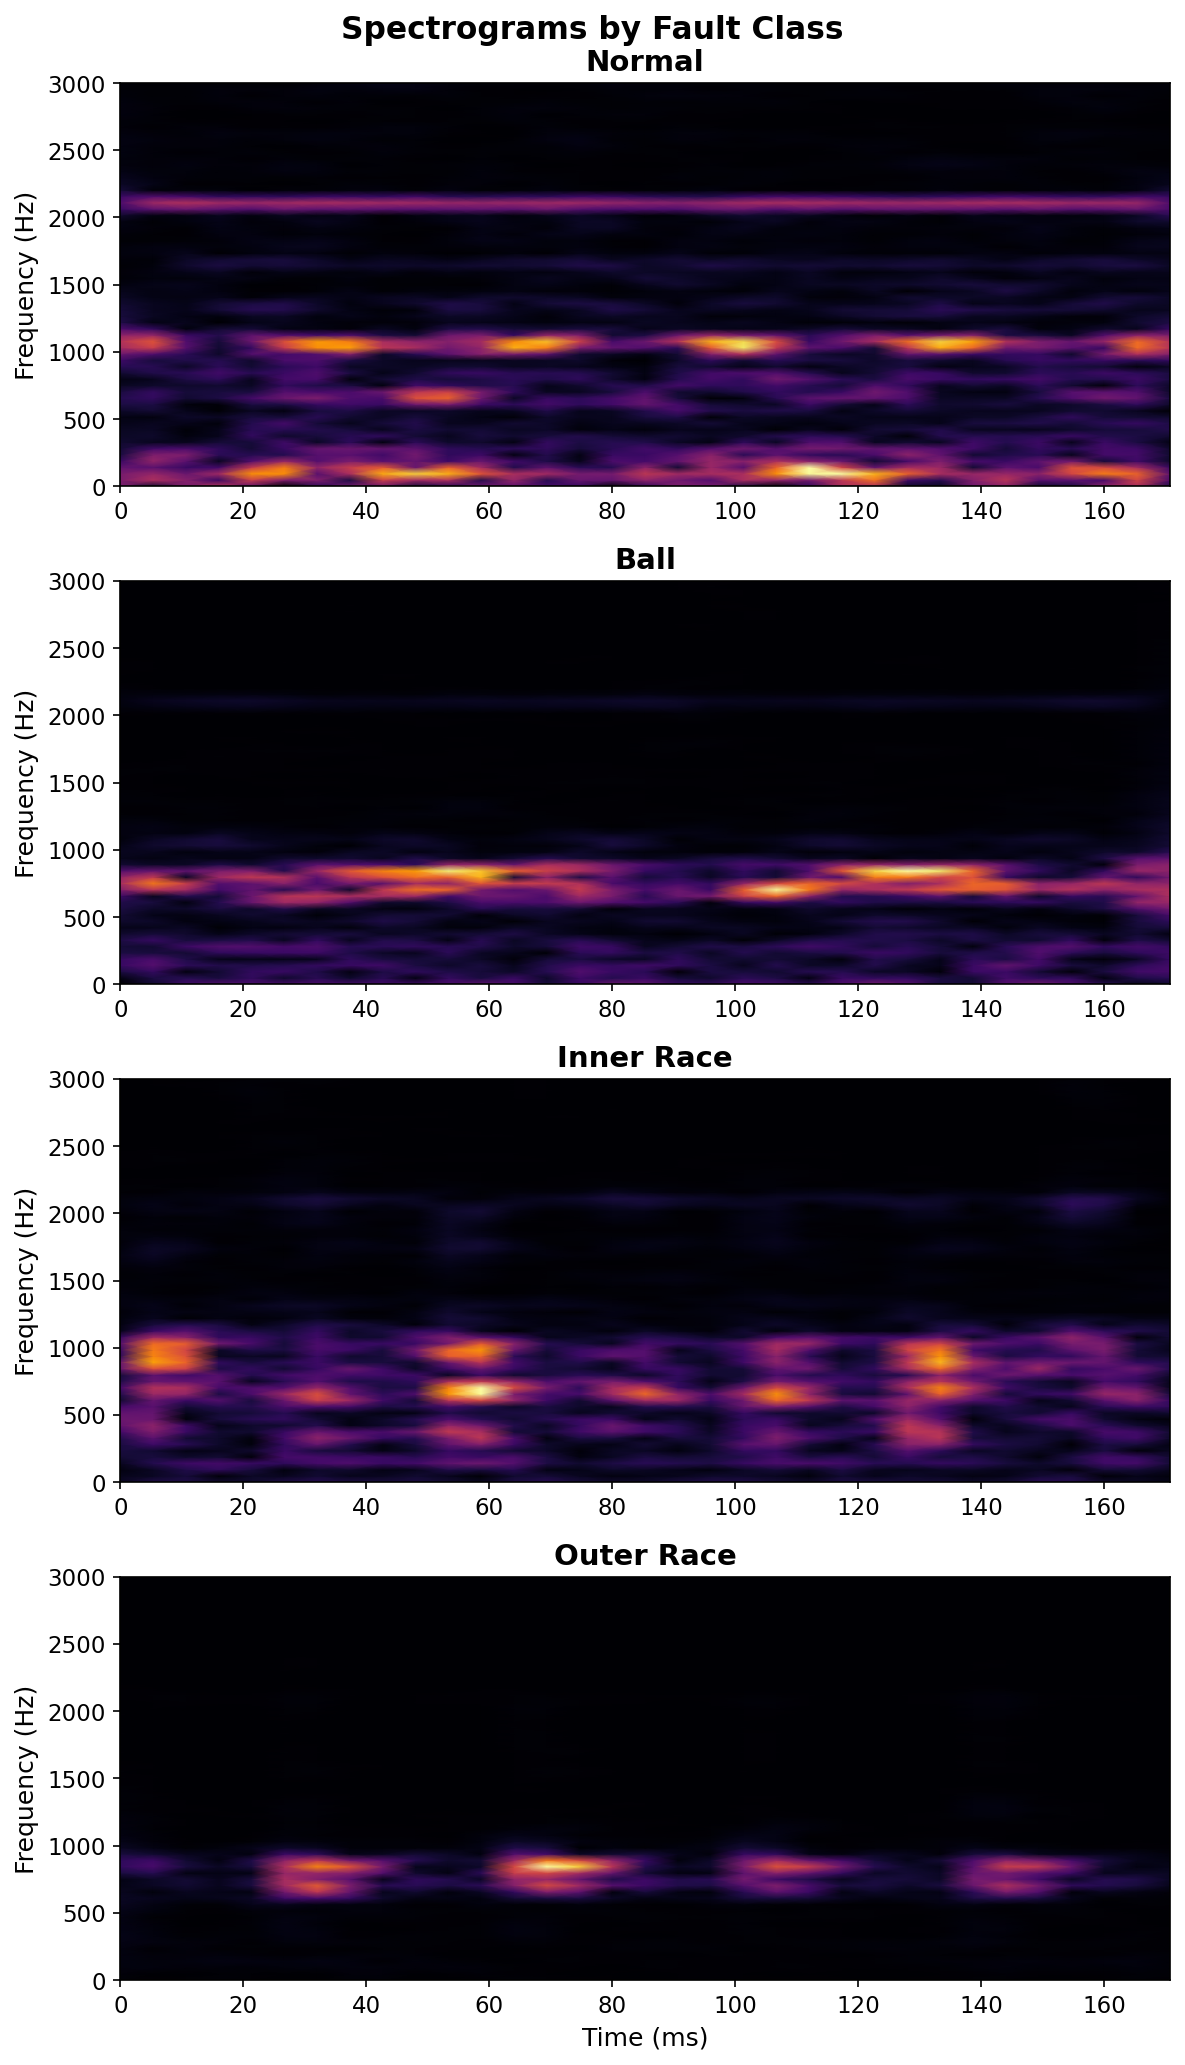

In [21]:
#  Spectrograms (time-frequency representation)

fig, axes = plt.subplots(4, 1, figsize=(8, 14))

for c in range(4):
    idx = np.where(y == c)[0][0]
    signal_window = X[idx]
    f_stft, t_stft, Zxx = stft(signal_window, fs=fs, nperseg=256, noverlap=192)

    axes[c].pcolormesh(t_stft * 1000, f_stft, np.abs(Zxx), shading='gouraud', cmap='inferno')
    axes[c].set_title(f'{class_names[c]}', fontsize=14, fontweight='bold')
    axes[c].set_ylabel('Frequency (Hz)', fontsize=12)
    axes[c].set_ylim([0, 3000])
    axes[c].tick_params(labelsize=11)

axes[3].set_xlabel('Time (ms)', fontsize=12)
fig.suptitle('Spectrograms by Fault Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_spectrograms.png'), bbox_inches='tight', dpi=150)
plt.show()


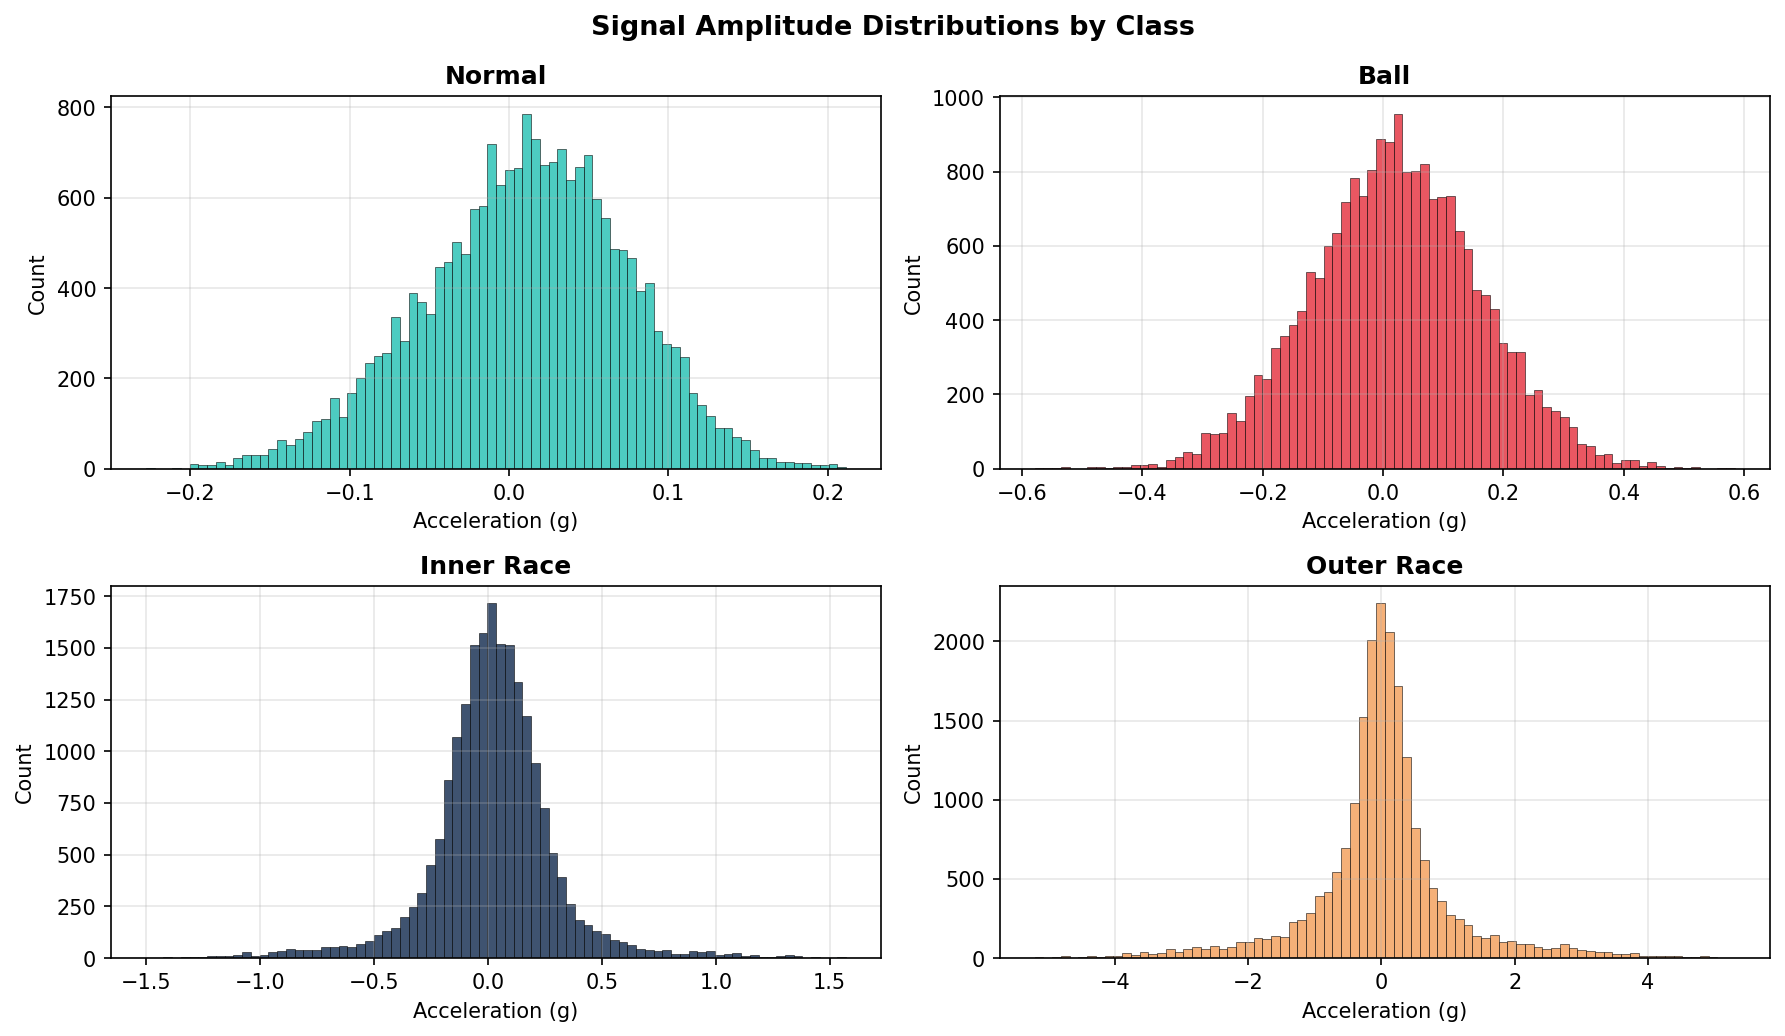

In [22]:
#  Signal amplitude distributions (histograms)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for c in range(4):
    # Sample 10 windows 
    class_indices = np.where(y == c)[0][:10]
    class_data = X[class_indices].flatten()

    axes[c].hist(class_data, bins=80, color=COLOURS[c], edgecolor="black", linewidth=0.3, alpha=0.85)
    axes[c].set_title(f"{class_names[c]}", fontweight="bold")
    axes[c].set_xlabel("Acceleration (g)")
    axes[c].set_ylabel("Count")
    axes[c].grid(True, alpha=0.3)

fig.suptitle("Signal Amplitude Distributions by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig6_amplitude_distributions.png"), bbox_inches="tight")
plt.show()


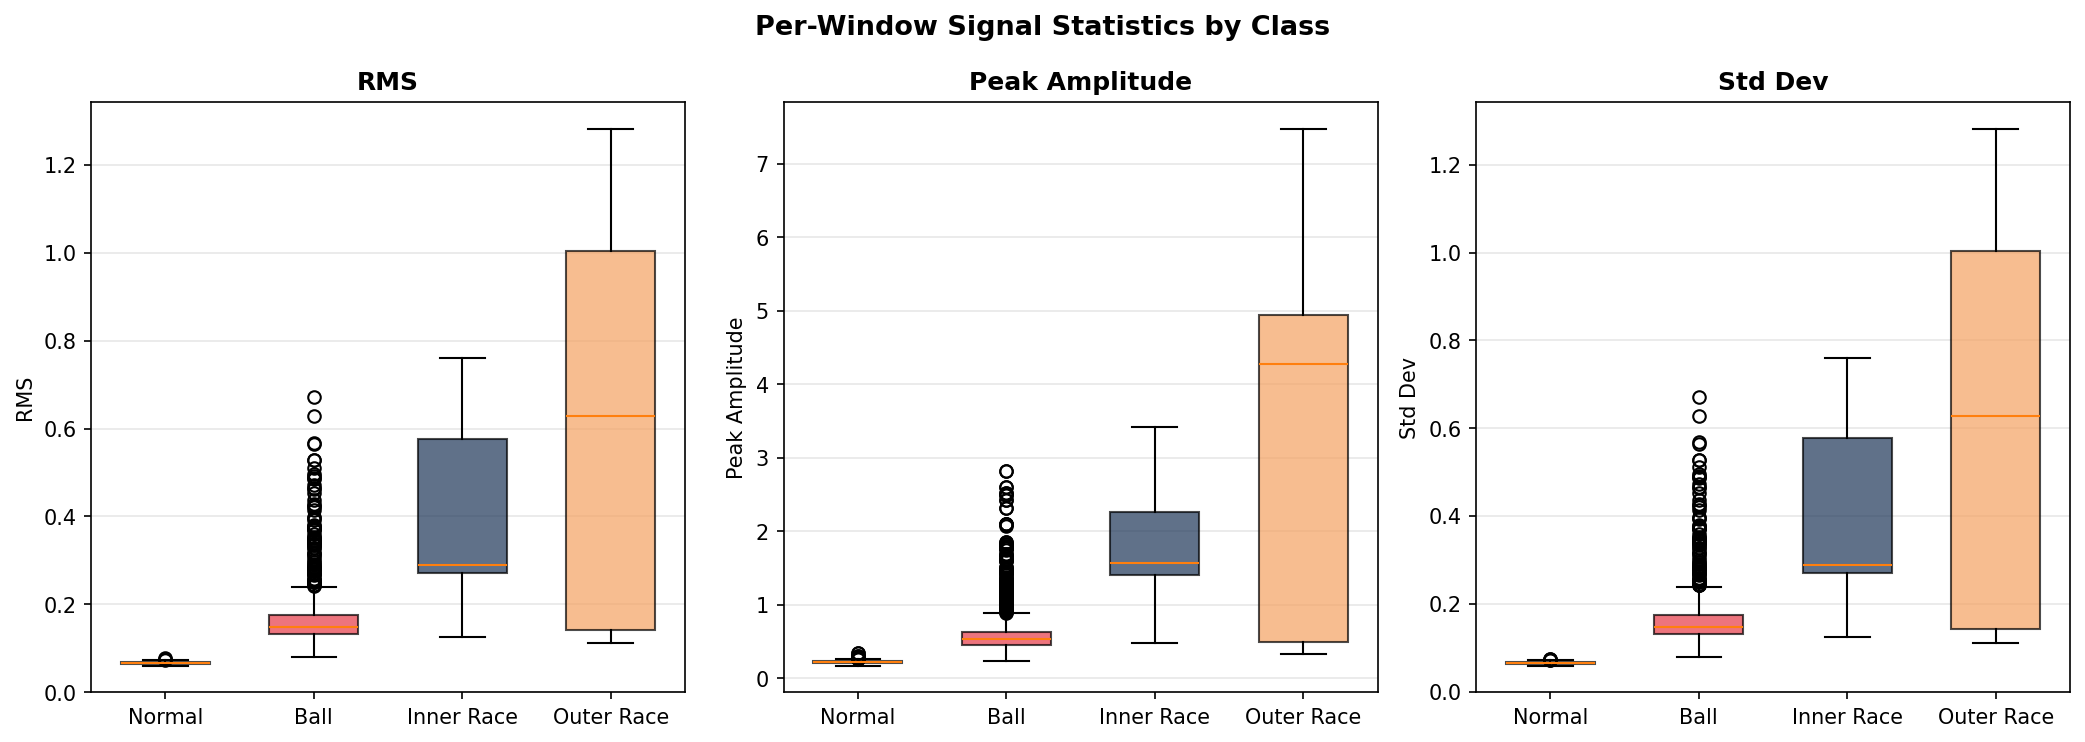

In [23]:
#  Box plots of per-window statistics by class

# compute per-window stats
rms_vals = np.sqrt(np.mean(X**2, axis=1))
peak_vals = np.max(np.abs(X), axis=1)
std_vals = np.std(X, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
stats = [("RMS", rms_vals), ("Peak Amplitude", peak_vals), ("Std Dev", std_vals)]

for ax, (stat_name, stat_data) in zip(axes, stats):
    data_by_class = [stat_data[y == c] for c in range(4)]
    bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True, widths=0.6)

    
    for patch, colour in zip(bp["boxes"], COLOURS):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    ax.set_title(stat_name, fontweight="bold")
    ax.set_ylabel(stat_name)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-Window Signal Statistics by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig7_boxplots_statistics.png"), bbox_inches="tight")
plt.show()


## 6) Feature Engineering

For the SVM baseline extract hand-crafted statistical and frequency-domain features from each window. These are standard features used in vibrationbased condition monitoring


In [25]:
# Extract features from each window

def extract_features(window, fs):
    """Extract time-domain and frequency-domain features from a single vibration window."""

    # Time-domain features
    rms = np.sqrt(np.mean(window**2))
    peak = np.max(np.abs(window))
    crest_factor = peak / rms if rms > 0 else 0
    kurt = kurtosis(window)
    skewness = skew(window)
    std = np.std(window)

    # Frequency-domain features (single-sided FFT)
    fft_vals = np.fft.fft(window)
    fft_mag = np.abs(fft_vals[:len(window) // 2])
    freqs = np.fft.fftfreq(len(window), d=1/fs)[:len(window) // 2]

    dominant_freq = freqs[np.argmax(fft_mag)]
    spectral_energy = np.sum(fft_mag**2)
    mean_freq = np.sum(freqs * fft_mag) / np.sum(fft_mag) if np.sum(fft_mag) > 0 else 0

    return [rms, peak, crest_factor, kurt, skewness, std,
            dominant_freq, mean_freq, spectral_energy]

feature_names = ["RMS", "Peak", "Crest Factor", "Kurtosis", "Skewness", "Std Dev",
                 "Dominant Freq", "Mean Freq", "Spectral Energy"]

# Extract features for all windows
print("Extracting features from all windows...")
X_features = np.array([extract_features(X[i], fs) for i in range(len(X))], dtype=np.float32)

print(f"Feature matrix shape: {X_features.shape}")
print(f"Features per window:  {len(feature_names)}")
print(f"Feature names:        {feature_names}")

Extracting features from all windows...
Feature matrix shape: (4630, 9)
Features per window:  9
Feature names:        ['RMS', 'Peak', 'Crest Factor', 'Kurtosis', 'Skewness', 'Std Dev', 'Dominant Freq', 'Mean Freq', 'Spectral Energy']


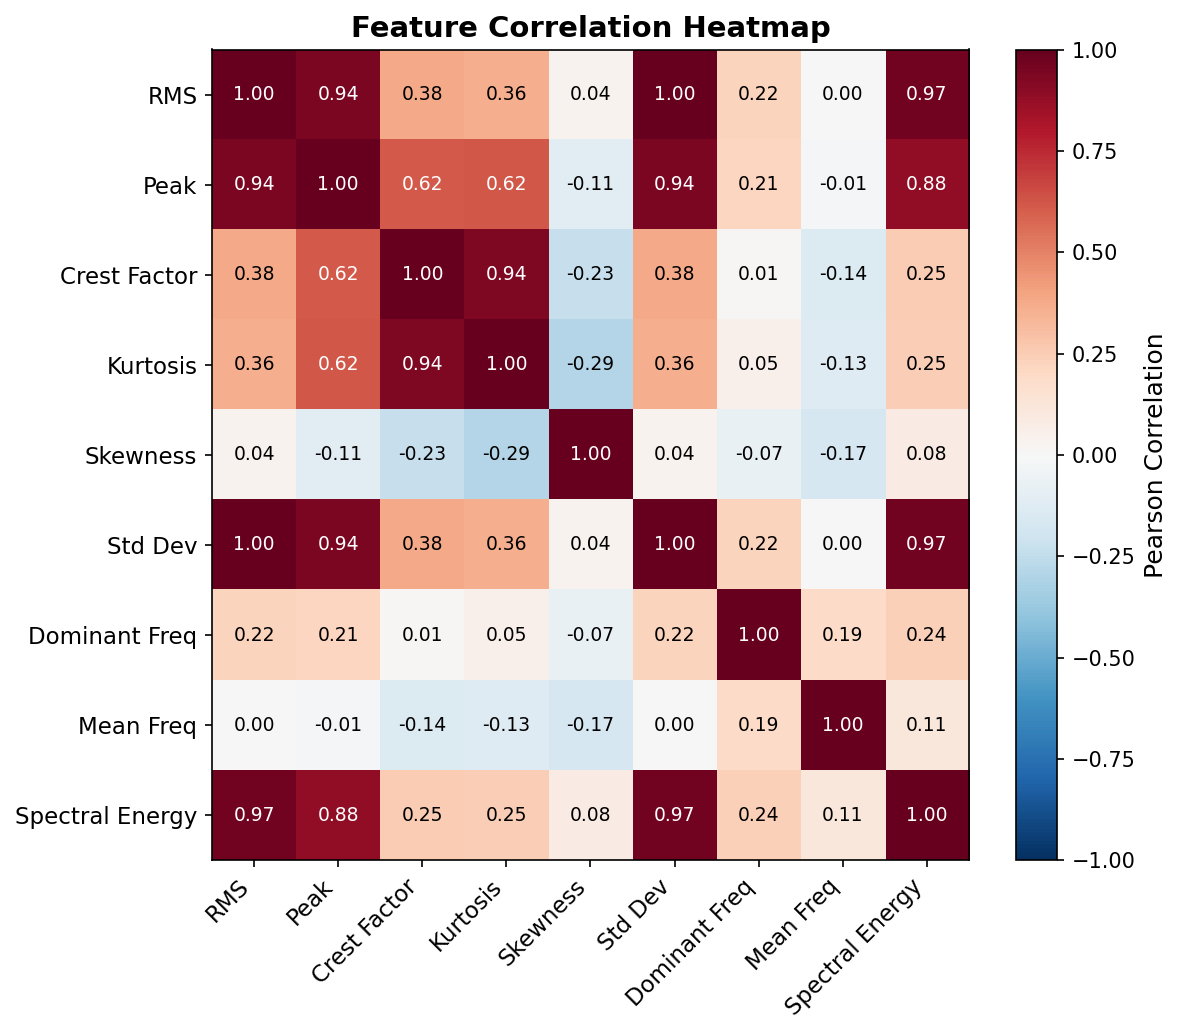

In [26]:
#  Feature correlation heatmap

corr_matrix = np.corrcoef(X_features.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(feature_names, fontsize=11)

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr_matrix[i, j]) > 0.6 else 'black')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson Correlation', fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig8_feature_correlation.png'), bbox_inches='tight', dpi=150)
plt.show()


## 7) Train / Validation / Test Split & Normalisation

We split the data into three sets:
- Training (70%) - used to update model weights
- Validation (15%) - used to monitor generalisation and tune hyperparameters
- Test (15%) - held out for final unbiased evaluation

stratified splits to maintain class proportions across all sets.



In [28]:
# Split raw windows (for LSTM) and features (for SVM)

# First split: 70% train 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 50/50 of temp - 15% val 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Same splits for the feature matrix using same indices
X_feat_train, X_feat_temp, _, _ = train_test_split(
    X_features, y, test_size=0.30, random_state=SEED, stratify=y
)
X_feat_val, X_feat_test, _, _ = train_test_split(
    X_feat_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Split sizes:")
print(f"  Train: {X_train.shape[0]:>5,d} windows  ({100*X_train.shape[0]/len(X):.0f}%)")
print(f"  Val:   {X_val.shape[0]:>5,d} windows  ({100*X_val.shape[0]/len(X):.0f}%)")
print(f"  Test:  {X_test.shape[0]:>5,d} windows  ({100*X_test.shape[0]/len(X):.0f}%)")

# Verify stratification
print("\nClass counts per split:")
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(labels)
    print(f"  {name}: {dict(zip(class_names, counts))}")

Split sizes:
  Train: 3,241 windows  (70%)
  Val:     694 windows  (15%)
  Test:    695 windows  (15%)

Class counts per split:
  Train: {'Normal': 330, 'Ball': 995, 'Inner Race': 921, 'Outer Race': 995}
  Val: {'Normal': 71, 'Ball': 213, 'Inner Race': 197, 'Outer Race': 213}
  Test: {'Normal': 70, 'Ball': 213, 'Inner Race': 198, 'Outer Race': 214}


In [29]:
# Normalise raw windows 

train_mean = np.mean(X_train)
train_std = np.std(X_train)

if train_std < 1e-8:
    train_std = 1e-8

X_train_n = (X_train - train_mean) / train_std
X_val_n   = (X_val   - train_mean) / train_std
X_test_n  = (X_test  - train_mean) / train_std

print("Raw window normalisation (using training stats only):")
print(f"  Train mean: {train_mean:.6f}")
print(f"  Train std:  {train_std:.6f}")
print(f"  After normalisation — Train mean: {np.mean(X_train_n):.6f}, std: {np.std(X_train_n):.6f}")

Raw window normalisation (using training stats only):
  Train mean: 0.014374
  Train std:  0.468467
  After normalisation — Train mean: 0.000000, std: 1.000000


In [30]:
# Normalise feature matrix (for SVM) using StandardScaler

scaler = StandardScaler()
X_feat_train_n = scaler.fit_transform(X_feat_train)  # fit on training data only
X_feat_val_n   = scaler.transform(X_feat_val)
X_feat_test_n  = scaler.transform(X_feat_test)

print("Feature normalisation complete (StandardScaler fitted on training set).")
print(f"  Feature matrix shapes — Train: {X_feat_train_n.shape}, Val: {X_feat_val_n.shape}, Test: {X_feat_test_n.shape}")

Feature normalisation complete (StandardScaler fitted on training set).
  Feature matrix shapes — Train: (3241, 9), Val: (694, 9), Test: (695, 9)


## 8) Baseline Model - Support Vector Machine
pros:
- Well-established in bearing fault diagnosis literature
- Works well with engineered features
- Does not require temporal modelling - tests whether hand-crafted features alone are sufficient
- Fast to train, interpretable decision boundaries

In [32]:
# Train SVM on hand-crafted features

print("Training SVM (RBF kernel) on extracted features...")

svm_model = SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)
svm_model.fit(X_feat_train_n, y_train)

# Evaluate on each split
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_feat_train_n))
svm_val_acc   = accuracy_score(y_val,   svm_model.predict(X_feat_val_n))
svm_test_acc  = accuracy_score(y_test,  svm_model.predict(X_feat_test_n))

print(f"  Train accuracy: {svm_train_acc:.4f}")
print(f"  Val accuracy:   {svm_val_acc:.4f}")
print(f"  Test accuracy:  {svm_test_acc:.4f}")

Training SVM (RBF kernel) on extracted features...
  Train accuracy: 0.9068
  Val accuracy:   0.8905
  Test accuracy:  0.8849


In [33]:
# SVM classification report and confusion matrix

y_pred_svm = svm_model.predict(X_feat_test_n)

print("SVM Classification Report (Test Set):")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

# Store metrics for later comparison
svm_f1 = f1_score(y_test, y_pred_svm, average="weighted")

SVM Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        70
        Ball       0.80      0.84      0.82       213
  Inner Race       0.95      0.92      0.94       198
  Outer Race       0.87      0.86      0.86       214

    accuracy                           0.88       695
   macro avg       0.91      0.90      0.91       695
weighted avg       0.89      0.88      0.89       695



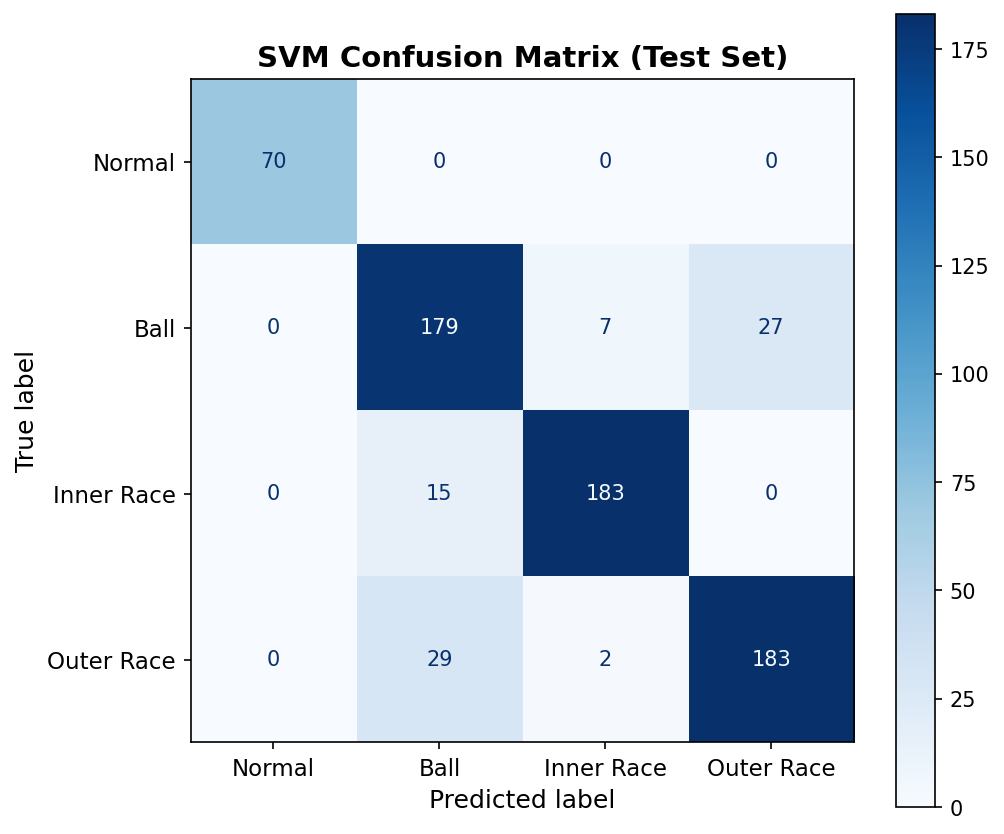

In [34]:
#  SVM Confusion Matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp_svm.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('SVM Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig9_svm_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()


## 9) Main Model - Long Short-Term Memory

The LSTM processes the raw windowed vibration signal as a time series, learning temporal patterns directly from the data 
pros:
- Vibration signals are inherently temporal 
- LSTMs can capture long-range dependencies
- Avoids information loss from manual feature extraction 
- Well-suited to sequential sensor data in mechatronics applications

Architecture:
- Input: normalised vibration window reshaped as a sequence of time steps
- LSTM layer with hidden state
- Fully connected output layer → 4 class logits
- Trained with cross-entropy loss and Adam optimiser

In [36]:
# PyTorch Dataset and DataLoaders for LSTM

# For the LSTM,  reshape each window into a sequence of sub-segments.
# Window of 2048 samples → 32 time steps of 64 samples each.

seq_steps = 32                                       # number time steps
step_len = window_length // seq_steps                # samples per time step (64)

class VibrationDataset(Dataset):
    def __init__(self, X_data, y_data):
    
        self.X = torch.tensor(X_data, dtype=torch.float32).reshape(-1, seq_steps, step_len)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_ds = VibrationDataset(X_train_n, y_train)
val_ds   = VibrationDataset(X_val_n, y_val)
test_ds  = VibrationDataset(X_test_n, y_test)

# create dataloaders
batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

print(f"LSTM input shape: ({seq_steps} time steps, {step_len} features per step)")
print(f"Batch size: {batch_size}")
print(f"DataLoaders created — Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}")

LSTM input shape: (32 time steps, 64 features per step)
Batch size: 64
DataLoaders created — Train: 51 batches, Val: 11, Test: 11


In [37]:
# LSTM model definition

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, n_classes, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,           # features per time step (64)
            hidden_size=hidden_size,         # LSTM hidden units
            num_layers=num_layers,           # stacked LSTM layers
            batch_first=True,                # input shape: (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_size, n_classes)  # output logits

    def forward(self, x):
        # x shape: (batch, seq_steps, step_len)
        lstm_out, (h_n, c_n) = self.lstm(x)

        # Use the last hidden state for classification
        last_hidden = h_n[-1]                # shape: (batch, hidden_size)

        out = self.dropout(last_hidden)
        out = self.fc(out)                   # shape: (batch, n_classes)
        return out

# Model hyperparameters
hidden_size = 128
num_layers = 2
n_classes = 4

model = LSTMClassifier(
    input_size=step_len,
    hidden_size=hidden_size,
    num_layers=num_layers,
    n_classes=n_classes,
    dropout=0.3
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"LSTM model created.")
print(f"  Hidden size:     {hidden_size}")
print(f"  LSTM layers:     {num_layers}")
print(f"  Total parameters: {total_params:,}")
print(model)

LSTM model created.
  Hidden size:     128
  LSTM layers:     2
  Total parameters: 231,940
LSTMClassifier(
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [38]:
# training setup

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Loss:      CrossEntropyLoss")
print("Optimiser: Adam (lr=1e-3)")

Loss:      CrossEntropyLoss
Optimiser: Adam (lr=1e-3)


In [39]:
# helper: evaluate model on a dataloader

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        total_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
        total_count += len(y_batch)

    avg_loss = total_loss / total_count
    accuracy = total_correct / total_count
    return avg_loss, accuracy

In [40]:
# Training loop

n_epochs = 30

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print(f"Training LSTM for {n_epochs} epochs...\n")

for epoch in range(1, n_epochs + 1):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_count = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(y_batch)
        running_correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
        running_count += len(y_batch)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print every 5 epochs 
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{n_epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.3f}")

print(f"\nTraining complete.")
print(f"Best validation accuracy: {max(val_accs):.4f} (epoch {np.argmax(val_accs)+1})")

Training LSTM for 30 epochs...

Epoch 01/30 | Train loss: 0.9283, acc: 0.620 | Val loss: 0.6938, acc: 0.713
Epoch 05/30 | Train loss: 0.1718, acc: 0.934 | Val loss: 0.1242, acc: 0.958
Epoch 10/30 | Train loss: 0.1055, acc: 0.960 | Val loss: 0.1034, acc: 0.958
Epoch 15/30 | Train loss: 0.1503, acc: 0.952 | Val loss: 0.0879, acc: 0.967
Epoch 20/30 | Train loss: 0.0309, acc: 0.990 | Val loss: 0.0654, acc: 0.978
Epoch 25/30 | Train loss: 0.0308, acc: 0.988 | Val loss: 0.1933, acc: 0.935
Epoch 30/30 | Train loss: 0.0104, acc: 0.997 | Val loss: 0.0731, acc: 0.974

Training complete.
Best validation accuracy: 0.9856 (epoch 26)


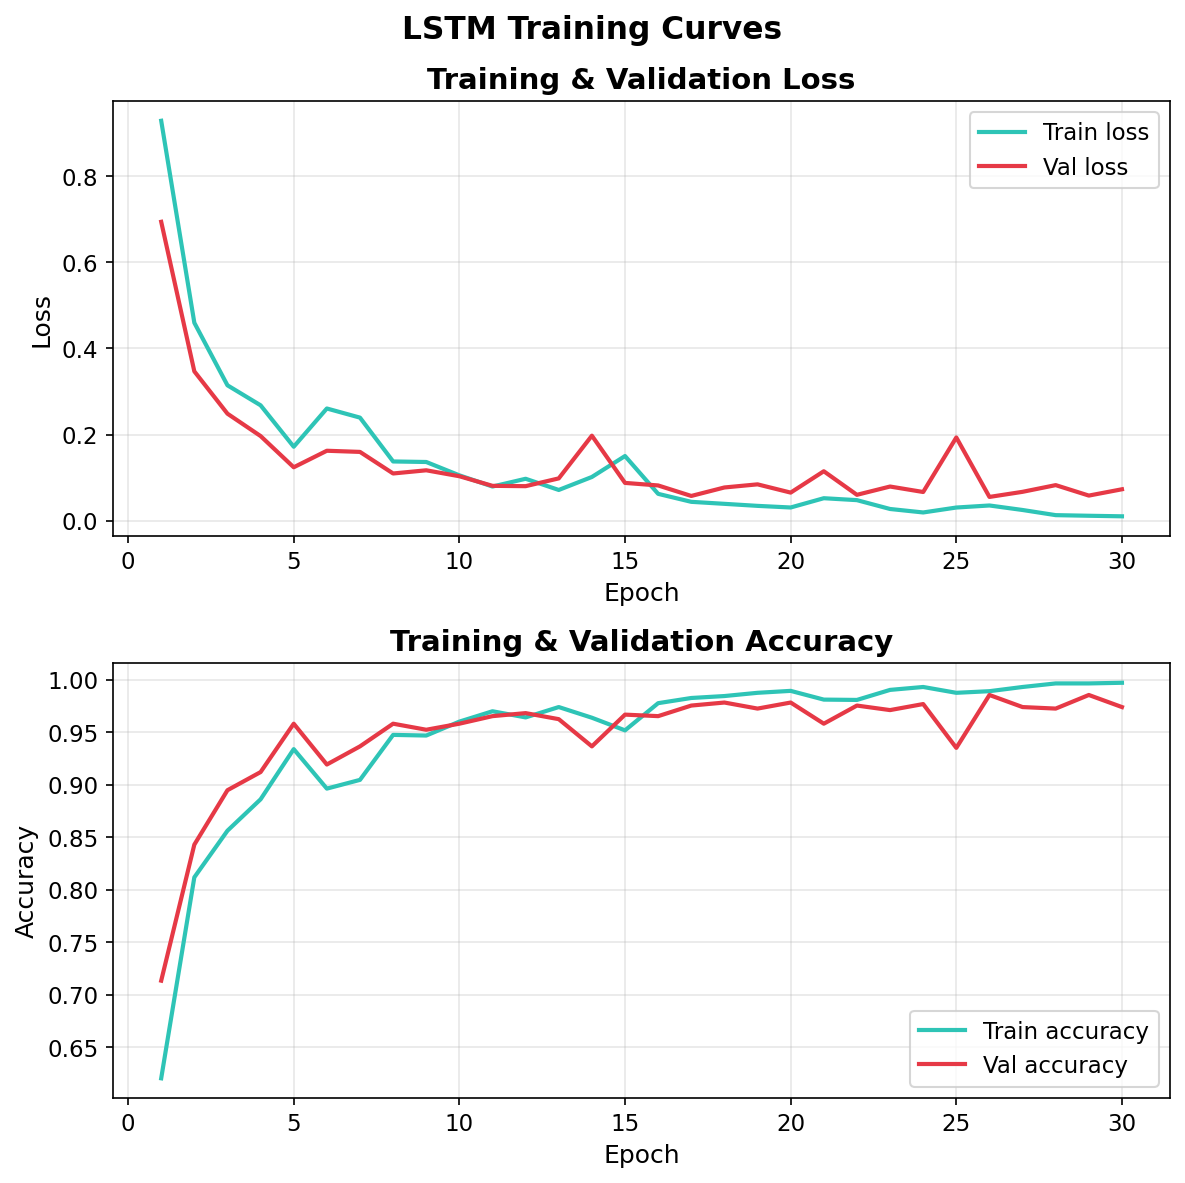

In [41]:
#  Training and validation curves

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

epochs_range = range(1, n_epochs + 1)

# Loss curves
ax1.plot(epochs_range, train_losses, color=TURQUOISE, linewidth=2, label='Train loss')
ax1.plot(epochs_range, val_losses, color=RED, linewidth=2, label='Val loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_range, train_accs, color=TURQUOISE, linewidth=2, label='Train accuracy')
ax2.plot(epochs_range, val_accs, color=RED, linewidth=2, label='Val accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)
ax2.grid(True, alpha=0.3)

fig.suptitle('LSTM Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_lstm_training_curves.png'), bbox_inches='tight', dpi=150)
plt.show()


In [42]:
# LSTM test evaluation and classification report

test_loss, test_acc = evaluate(model, test_loader)
print(f"LSTM Test loss:     {test_loss:.4f}")
print(f"LSTM Test accuracy: {test_acc:.4f}")

# Get predictions for full test set
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_true_all.append(y_batch.numpy())
        y_pred_all.append(preds)
        y_proba_all.append(probs.cpu().numpy())

    return (np.concatenate(y_true_all),
            np.concatenate(y_pred_all),
            np.concatenate(y_proba_all))

y_true_lstm, y_pred_lstm, y_proba_lstm = predict_all(model, test_loader)

print("\nLSTM Classification Report (Test Set):")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=class_names))

lstm_f1 = f1_score(y_true_lstm, y_pred_lstm, average="weighted")

LSTM Test loss:     0.0577
LSTM Test accuracy: 0.9871

LSTM Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        70
        Ball       0.97      0.99      0.98       213
  Inner Race       0.99      1.00      0.99       198
  Outer Race       1.00      0.97      0.98       214

    accuracy                           0.99       695
   macro avg       0.99      0.99      0.99       695
weighted avg       0.99      0.99      0.99       695



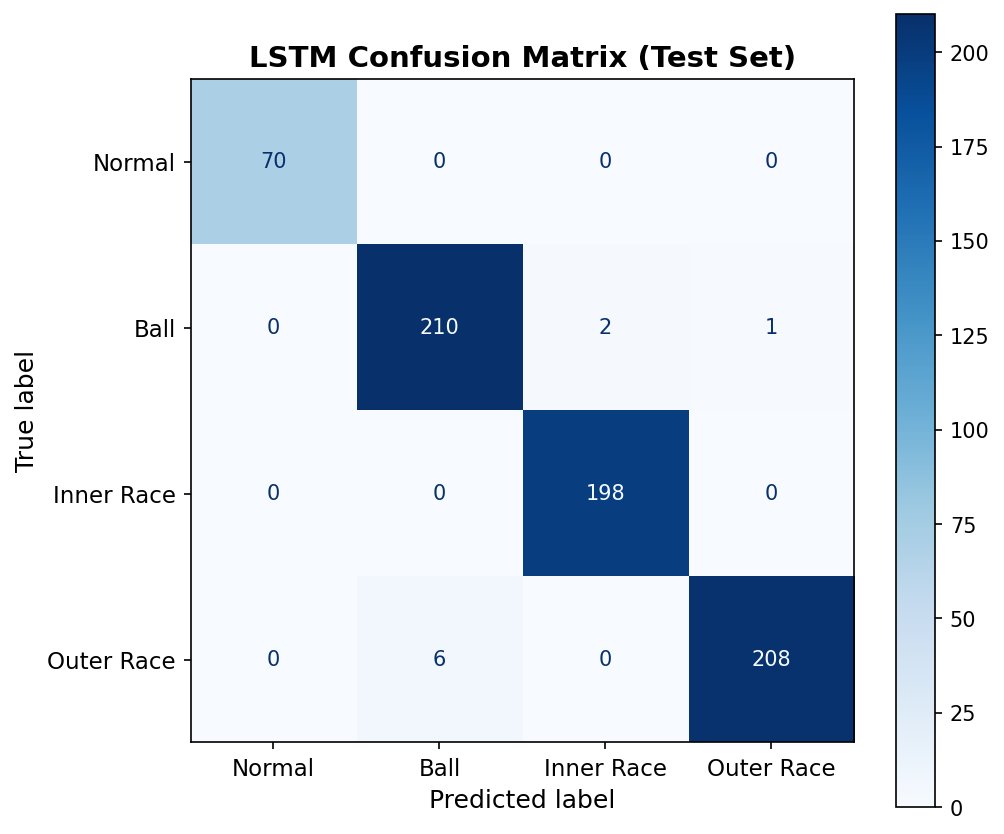

In [43]:
# F LSTM Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm_lstm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('LSTM Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig11_lstm_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()


Model Comparison:
    Model  Test Accuracy  Test F1 (weighted)
SVM (RBF)       0.884892            0.885520
     LSTM       0.987050            0.987043


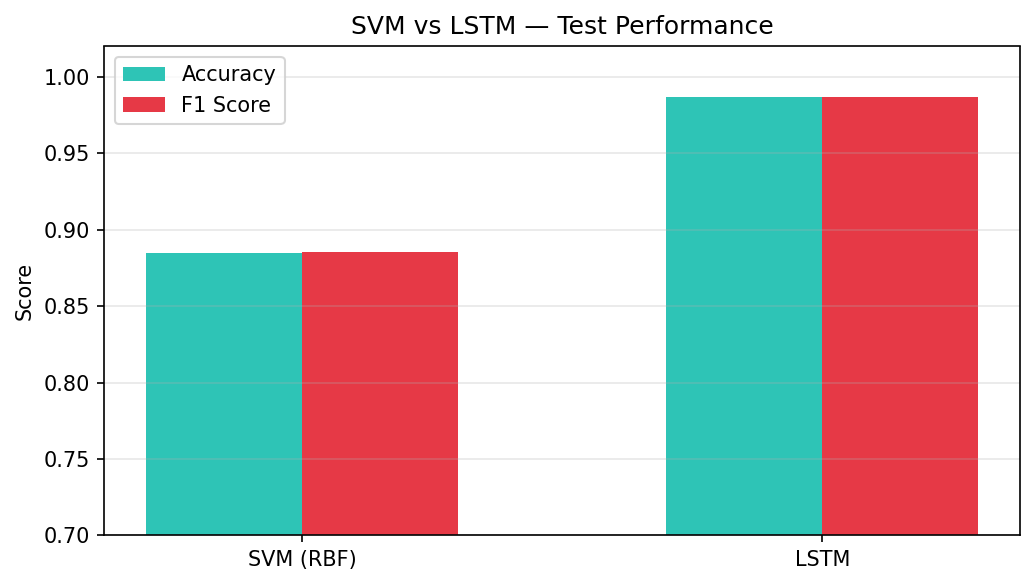

In [44]:
# Results comparison: SVM vs LSTM

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SVM (RBF)", "LSTM"],
    "Test Accuracy": [svm_test_acc, test_acc],
    "Test F1 (weighted)": [svm_f1, lstm_f1],
})
print("Model Comparison:")
print(comparison.to_string(index=False))


fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(2)
bar_w = 0.3

ax.bar(x_pos - bar_w/2, [svm_test_acc, test_acc], bar_w, label="Accuracy", color="#2EC4B6")
ax.bar(x_pos + bar_w/2, [svm_f1, lstm_f1], bar_w, label="F1 Score", color="#E63946")

ax.set_xticks(x_pos)
ax.set_xticklabels(["SVM (RBF)", "LSTM"])
ax.set_ylabel("Score")
ax.set_title("SVM vs LSTM — Test Performance")
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig12_model_comparison.png"), bbox_inches="tight")
plt.show()


## 10) Ablation & Sensitivity Analysis

To understand how sensitive the results are to design choices, we test three things:
removing redundant features from the SVM, changing the window length, and varying the SVM regularisation parameter.
This helps confirm the pipeline is robust and highlights which decisions matter most.


In [46]:
# 10a) SVM feature ablation - remove correlated features
# From the correlation heatmap ), RMS/Peak/StdDev/SpectralEnergy
# are highly correlated (>0.88). What happens if we drop the redundant ones

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

all_idx = list(range(len(feature_names)))

# Drop Peak (1), Std Dev (5), Spectral Energy (8) - highly correlated with RMS
reduced_idx = [i for i in all_idx if i not in [1, 5, 8]]

# Minimal set: just RMS, Kurtosis, Dominant Freq (3 features)
minimal_idx = [0, 3, 6]

subsets = {
    "All 9 features": all_idx,
    "6 features (drop correlated)": reduced_idx,
    "3 features (RMS, Kurtosis, Dom. Freq)": minimal_idx,
}

print("SVM Feature Ablation (RBF kernel, C=10)")
print("=" * 60)

ablation_results = []
for name, idx in subsets.items():
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(X_feat_train[:, idx])
    Xval_s = sc.transform(X_feat_val[:, idx])
    Xte_s = sc.transform(X_feat_test[:, idx])

    svm_ab = SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)
    svm_ab.fit(Xtr_s, y_train)

    acc = accuracy_score(y_test, svm_ab.predict(Xte_s))
    f1 = f1_score(y_test, svm_ab.predict(Xte_s), average="weighted")
    feat_used = [feature_names[i] for i in idx]

    ablation_results.append({"Subset": name, "N": len(idx), "Acc": acc, "F1": f1})
    print(f"{name:<40s} | Acc: {acc:.4f} | F1: {f1:.4f}")
    print(f"  Features: {feat_used}")



SVM Feature Ablation (RBF kernel, C=10)
All 9 features                           | Acc: 0.8849 | F1: 0.8855
  Features: ['RMS', 'Peak', 'Crest Factor', 'Kurtosis', 'Skewness', 'Std Dev', 'Dominant Freq', 'Mean Freq', 'Spectral Energy']
6 features (drop correlated)             | Acc: 0.8849 | F1: 0.8855
  Features: ['RMS', 'Crest Factor', 'Kurtosis', 'Skewness', 'Dominant Freq', 'Mean Freq']
3 features (RMS, Kurtosis, Dom. Freq)    | Acc: 0.8647 | F1: 0.8634
  Features: ['RMS', 'Kurtosis', 'Dominant Freq']


In [47]:
# 10b) Window size sensitivity analysis
#  pipeline uses 2048-sample windows. ow does changing this affect results?

from scipy.stats import kurtosis, skew

window_sizes = [512, 1024, 2048, 4096]
window_results = []

print("Window Size Sensitivity (SVM with all 9 features)")
print("=" * 60)

for wl in window_sizes:
    step = wl // 2

   
    Xw = []
    yw = []
    for fname in raw_signals:
        signal = raw_signals[fname]
        label = raw_labels[fname]
        lbl = label_map[label]
        n_windows = (len(signal) - wl) // step + 1
        for j in range(n_windows):
            window = signal[j * step : j * step + wl]
            Xw.append(window)
            yw.append(lbl)

    Xw = np.array(Xw, dtype=np.float32)
    yw = np.array(yw)

    
    feats_w = np.array([extract_features(Xw[i], fs) for i in range(len(Xw))], dtype=np.float32)

    # split (same ratio and seed)
    Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(
        feats_w, yw, test_size=0.30, random_state=SEED, stratify=yw
    )
    Xte_w, _, yte_w, _ = train_test_split(
        Xte_w, yte_w, test_size=0.50, random_state=SEED, stratify=yte_w
    )

    sc_w = StandardScaler()
    Xtr_wn = sc_w.fit_transform(Xtr_w)
    Xte_wn = sc_w.transform(Xte_w)

    svm_w = SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)
    svm_w.fit(Xtr_wn, ytr_w)

    acc_w = accuracy_score(yte_w, svm_w.predict(Xte_wn))
    f1_w = f1_score(yte_w, svm_w.predict(Xte_wn), average="weighted")
    n_win = len(Xw)

    window_results.append({"Window": wl, "Windows": n_win, "Acc": acc_w, "F1": f1_w})
    duration_ms = wl / fs * 1000
    print(f"Window: {wl:5d} samples ({duration_ms:6.1f} ms) | "
          f"Windows: {n_win:5d} | Acc: {acc_w:.4f} | F1: {f1_w:.4f}")



Window Size Sensitivity (SVM with all 9 features)
Window:   512 samples (  42.7 ms) | Windows: 18570 | Acc: 0.8043 | F1: 0.8031
Window:  1024 samples (  85.3 ms) | Windows:  9277 | Acc: 0.8398 | F1: 0.8390
Window:  2048 samples ( 170.7 ms) | Windows:  4630 | Acc: 0.8905 | F1: 0.8916
Window:  4096 samples ( 341.3 ms) | Windows:  2307 | Acc: 0.9393 | F1: 0.9390


In [48]:
# 10c) SVM regularisation (C parameter) sensitivity
# C controls the trade-off between margin width and misclassification.


c_values = [0.01, 0.1, 1, 10, 100, 1000]
c_results = []

print("SVM C-Parameter Sensitivity (RBF kernel, all 9 features)")
print("=" * 60)

for c_val in c_values:
    svm_c = SVC(kernel="rbf", C=c_val, gamma="scale", random_state=SEED)
    svm_c.fit(X_feat_train_n, y_train)

    acc_c = accuracy_score(y_test, svm_c.predict(X_feat_test_n))
    f1_c = f1_score(y_test, svm_c.predict(X_feat_test_n), average="weighted")
    acc_v = accuracy_score(y_val, svm_c.predict(X_feat_val_n))

    c_results.append({"C": c_val, "Val Acc": acc_v, "Test Acc": acc_c, "Test F1": f1_c})
    print(f"C = {c_val:<8} | Val Acc: {acc_v:.4f} | Test Acc: {acc_c:.4f} | Test F1: {f1_c:.4f}")



SVM C-Parameter Sensitivity (RBF kernel, all 9 features)
C = 0.01     | Val Acc: 0.7795 | Test Acc: 0.7942 | Test F1: 0.7940
C = 0.1      | Val Acc: 0.8314 | Test Acc: 0.8374 | Test F1: 0.8363
C = 1        | Val Acc: 0.8401 | Test Acc: 0.8576 | Test F1: 0.8572
C = 10       | Val Acc: 0.8905 | Test Acc: 0.8849 | Test F1: 0.8855
C = 100      | Val Acc: 0.9006 | Test Acc: 0.8892 | Test F1: 0.8896
C = 1000     | Val Acc: 0.8991 | Test Acc: 0.8921 | Test F1: 0.8919


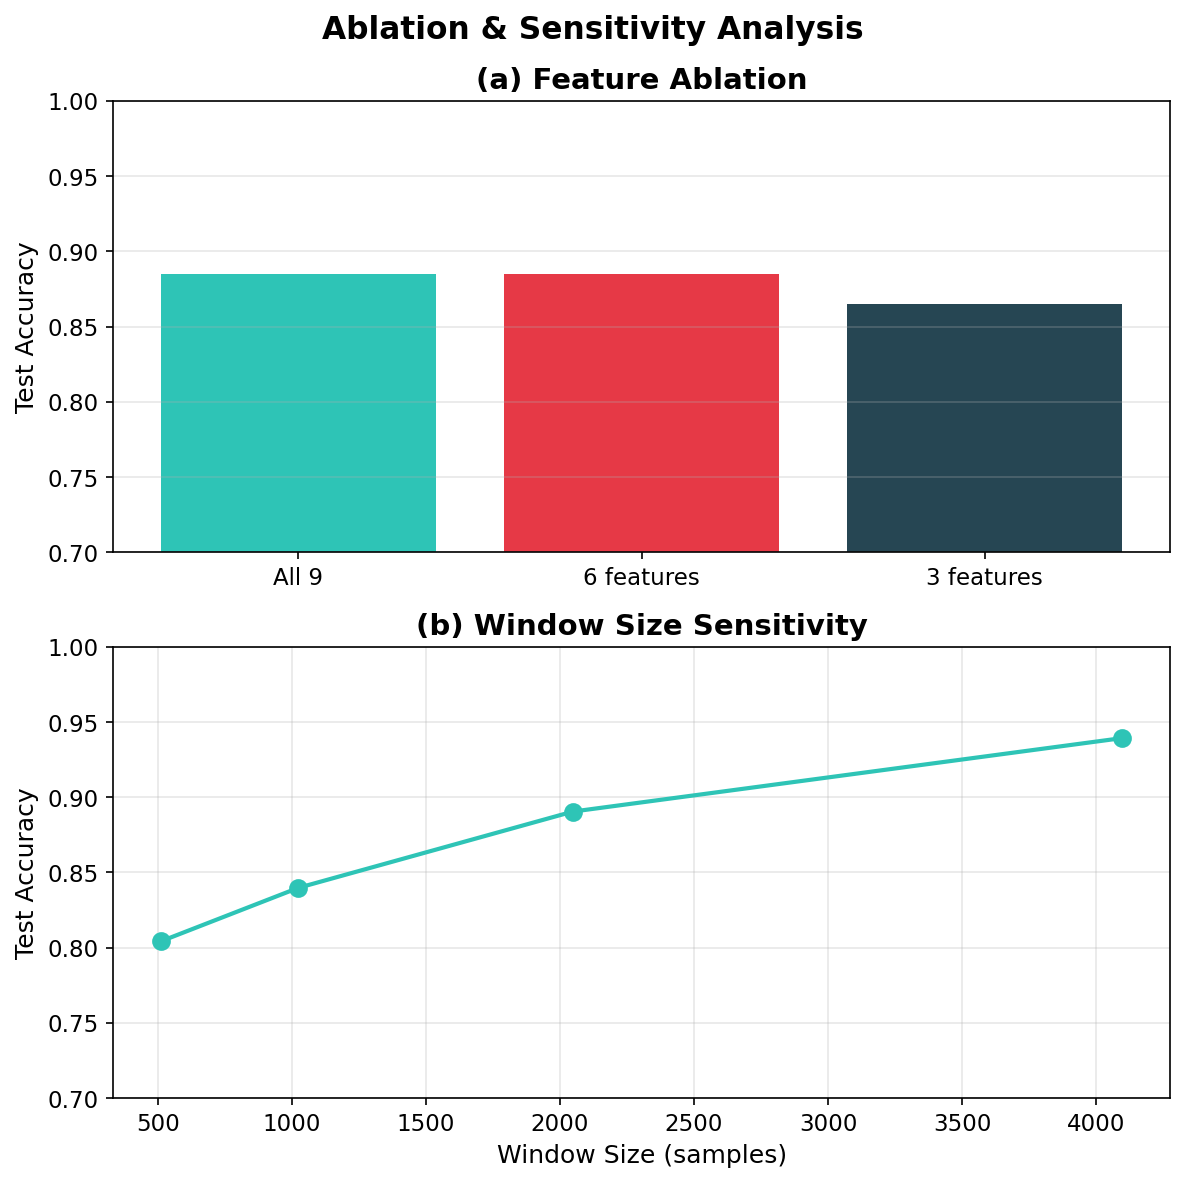

In [49]:


fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# (a) Feature ablation
ax = axes[0]
accs_a = [r['Acc'] for r in ablation_results]
ax.bar(range(len(accs_a)), accs_a, color=['#2EC4B6', '#E63946', '#264653'])
ax.set_xticks(range(len(accs_a)))
ax.set_xticklabels(['All 9', '6 features', '3 features'], fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('(a) Feature Ablation', fontsize=14, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.tick_params(labelsize=11)
ax.grid(axis='y', alpha=0.3)

# (b) Window size
ax = axes[1]
ws = [r['Window'] for r in window_results]
accs_w = [r['Acc'] for r in window_results]
ax.plot(ws, accs_w, 'o-', color='#2EC4B6', linewidth=2, markersize=8)
ax.set_xlabel('Window Size (samples)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('(b) Window Size Sensitivity', fontsize=14, fontweight='bold')
ax.set_ylim(0.7, 1.0)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)

fig.suptitle('Ablation & Sensitivity Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig13_ablation_sensitivity.png'), bbox_inches='tight', dpi=150)
plt.show()
